Assignment on Linear Regression: Ridge linear regression (Note that the regularization term is not applied to $\theta_0$)


$$J(\theta)=\left(\frac{1}{2} \sum_{i=1}^m\left(h_\theta\left(x^{(i)}\right)-y^{(i)}\right)^2\right)+\frac{1}{2} \lambda\|\hat{\theta}\|_2^2$$

where $\hat{\theta}$ is given by $$[0 \ \theta_1 \ \theta_2 \ \ldots \ \theta_n]$$
i.e., is as vector $\theta$ defined in class, but with $\theta_0 = 0$, since we do not regularize $\theta_0$.



In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Synthetic data generation

In [2]:
np.random.seed(123)
# Generate random x values
x = np.random.uniform(-10, 10, size=(100,))

# Generate corresponding y values with some noise
y = 2 + 2.5 * x + np.random.normal(0, 1, size=(100,))

# Reshape x to a 2D array
x = x.reshape(-1, 1)

print(x.shape)

(100, 1)


How does the data look like?

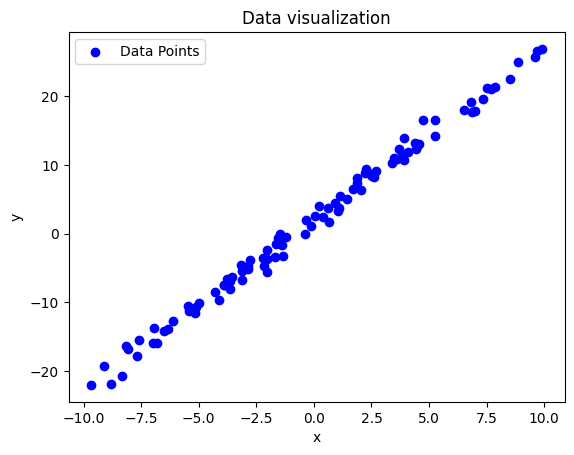

In [3]:
# Data visualization
plt.scatter(x, y, c='b', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data visualization')
plt.legend()
plt.show()

Let's fit some lines to the data

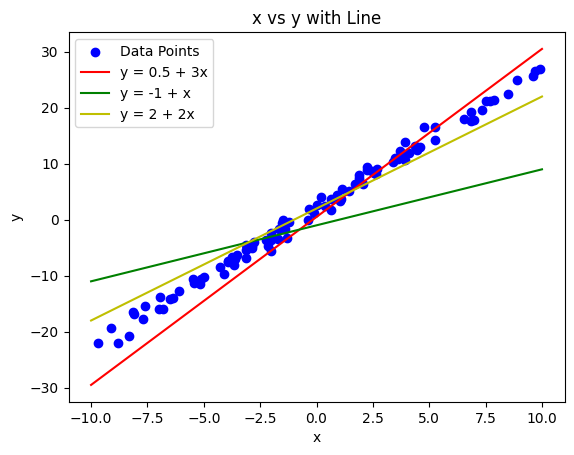

In [4]:
# Plot x vs y as scatter plot
plt.scatter(x, y, c='b', label='Data Points')

# Generate the line y = 0.5 + 3x
x_line = np.linspace(-10, 10, 100)
y_line_1 = 0.5 + 3 * x_line
y_line_2 = -1 + 1 * x_line
y_line_3 = 2 + 2 * x_line

# Plot the line on top of the scatter plot
plt.plot(x_line, y_line_1, c='r', label='y = 0.5 + 3x')
plt.plot(x_line, y_line_2, c='g', label='y = -1 + x')
plt.plot(x_line, y_line_3, c='y', label='y = 2 + 2x')

plt.xlabel('x')
plt.ylabel('y')
plt.title('x vs y with Line')
plt.legend()
plt.show()

In this assignment, you will find the parameters $\theta$ that minimize the cost function defined above.

For this assignment, do not split the data in train and test sets, and do not normalize the data. In other words, just use the data as is.

Part A: sklearn ridge

Intercept (θ₀): 2.0354
Slope (θ₁): 2.4862


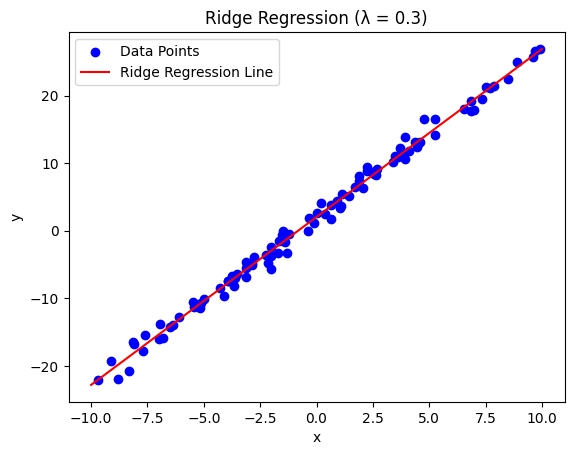

In [5]:
from sklearn.linear_model import Ridge

# Create and fit the Ridge model with lambda = 0.3
lambda_ridge = 0.3
ridge_model = Ridge(alpha=lambda_ridge, fit_intercept=True)

# Add a column of ones to x for the intercept term
X = np.hstack([np.ones((x.shape[0], 1)), x])

# Fit the model
ridge_model.fit(x, y)

# Get the coefficients
theta_0 = ridge_model.intercept_
theta_1 = ridge_model.coef_[0]

print(f"Intercept (θ₀): {theta_0:.4f}")
print(f"Slope (θ₁): {theta_1:.4f}")

# Plot the results
plt.scatter(x, y, c='b', label='Data Points')
x_line = np.linspace(-10, 10, 100).reshape(-1, 1)
y_pred = ridge_model.predict(x_line)

plt.plot(x_line, y_pred, c='r', label='Ridge Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ridge Regression (λ = 0.3)')
plt.legend()
plt.show()

Part B: Normal Equations

Compute the optimal values of $\theta$ using the normal equation derived in the HW:

$$\hat{\theta} = (X^TX + \lambda A)^{-1}X^TY,$$

where A is like the identity matrix I, but with entry (0,0) equal to 0.

Normal Equations:
Intercept (θ₀): 2.0354
Slope (θ₁): 2.4862


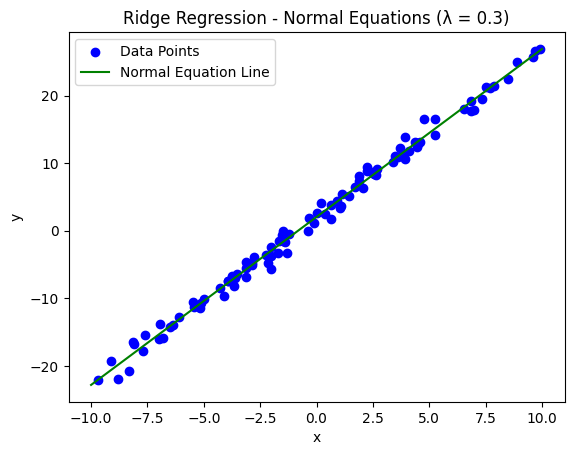

In [6]:
# Find the optimal value of theta using the normal equation
lambda_ridge = 0.3

# Add column of ones to x for intercept term
X = np.hstack([np.ones((x.shape[0], 1)), x])

# Create matrix A (identity matrix with first element set to 0)
n = X.shape[1]  # number of features + 1
A = np.eye(n)
A[0,0] = 0

# Calculate theta using the normal equation
theta = np.linalg.inv(X.T @ X + lambda_ridge * A) @ X.T @ y

# Extract coefficients
theta_0 = theta[0]
theta_1 = theta[1]

print(f"Normal Equations:")
print(f"Intercept (θ₀): {theta_0:.4f}")
print(f"Slope (θ₁): {theta_1:.4f}")

# Plot the results
plt.scatter(x, y, c='b', label='Data Points')
x_line = np.linspace(-10, 10, 100)
y_pred = theta_0 + theta_1 * x_line

plt.plot(x_line, y_pred, c='g', label='Normal Equation Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ridge Regression - Normal Equations (λ = 0.3)')
plt.legend()
plt.show()

Part C: Gradient Descent

2) Implement the GD rule you derived

Gradient Descent:
Intercept (θ₀): 0.0807
Slope (θ₁): 2.4427


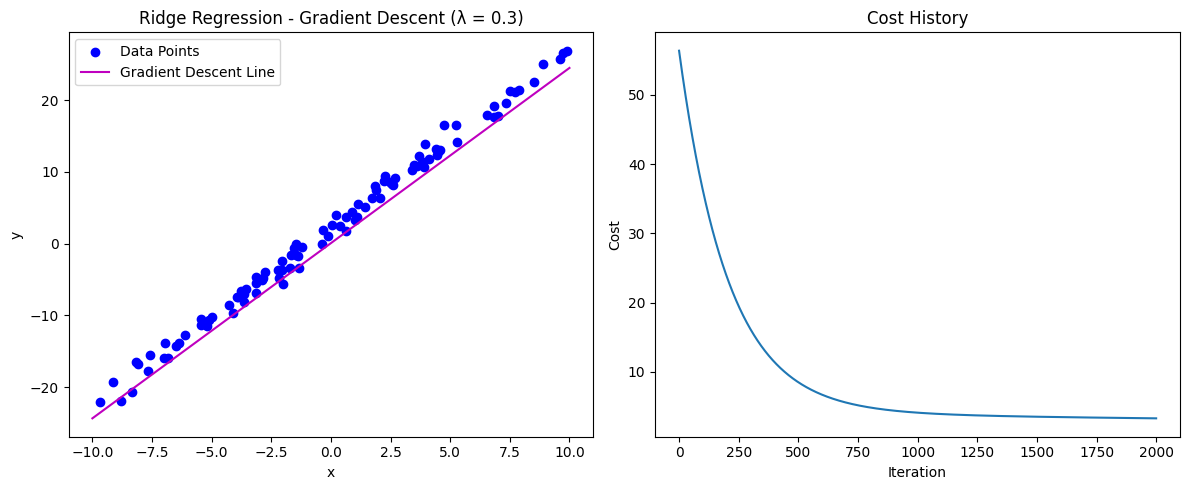

In [7]:
# Gradient descent
# Set value of learning rate
alpha = 0.0001
# Set maximum number of iterations
numIter = 2000

# Initialize theta randomly
theta = np.random.randn(2)

# Add column of ones to x for intercept term
X = np.hstack([np.ones((x.shape[0], 1)), x])

# Create matrix A for ridge regularization
n = X.shape[1]
A = np.eye(n)
A[0,0] = 0

# Store the cost history
cost_history = []

# Gradient Descent
m = X.shape[0]
for i in range(numIter):
    # Compute hypothesis
    h = X @ theta
    
    # Compute gradients
    grad = (1/m) * X.T @ (h - y) + lambda_ridge * A @ theta
    
    # Update theta
    theta = theta - alpha * grad
    
    # Compute and store cost
    cost = (1/(2*m)) * np.sum((h - y)**2) + (lambda_ridge/2) * (theta[1:]**2).sum()
    cost_history.append(cost)

# Extract final coefficients
theta_0_gd = theta[0]
theta_1_gd = theta[1]

print(f"Gradient Descent:")
print(f"Intercept (θ₀): {theta_0_gd:.4f}")
print(f"Slope (θ₁): {theta_1_gd:.4f}")

# Plot the results
plt.figure(figsize=(12, 5))

# Plot 1: Regression line
plt.subplot(1, 2, 1)
plt.scatter(x, y, c='b', label='Data Points')
x_line = np.linspace(-10, 10, 100)
y_pred = theta_0_gd + theta_1_gd * x_line

plt.plot(x_line, y_pred, c='m', label='Gradient Descent Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Ridge Regression - Gradient Descent (λ = 0.3)')
plt.legend()

# Plot 2: Cost history
plt.subplot(1, 2, 2)
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History')

plt.tight_layout()
plt.show()

Part D: Compare the results

Comparison of θ values from all methods:

Scikit-learn Ridge:
Intercept (θ₀): 2.0354
Slope (θ₁): 2.4862

Normal Equations:
Intercept (θ₀): 2.0354
Slope (θ₁): 2.4862

Gradient Descent:
Intercept (θ₀): 0.0807
Slope (θ₁): 2.4427


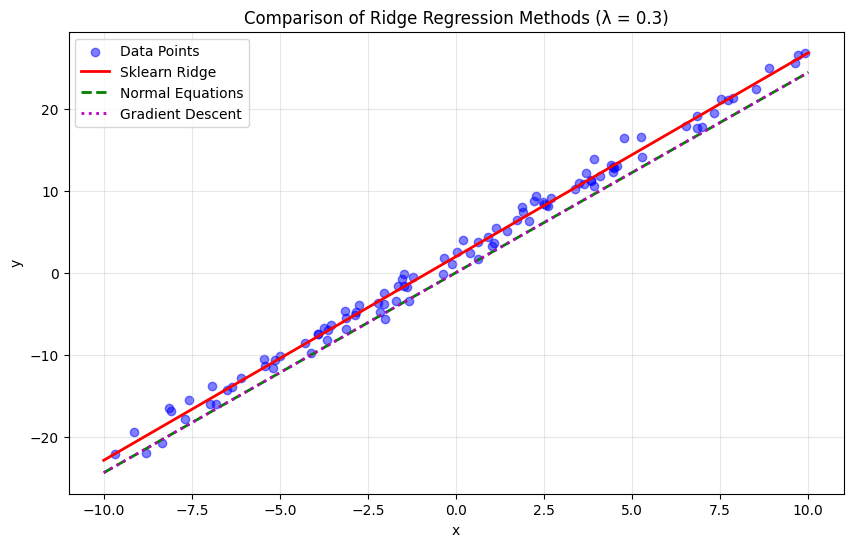

In [11]:
# Compare all results
print("Comparison of θ values from all methods:")
print("\nScikit-learn Ridge:")
print(f"Intercept (θ₀): {theta_0:.4f}")
print(f"Slope (θ₁): {theta_1:.4f}")

print("\nNormal Equations:")
print(f"Intercept (θ₀): {theta_0:.4f}")
print(f"Slope (θ₁): {theta_1:.4f}")

print("\nGradient Descent:")
print(f"Intercept (θ₀): {theta_0_gd:.4f}")
print(f"Slope (θ₁): {theta_1_gd:.4f}")

# Plot all three lines together
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='b', label='Data Points', alpha=0.5)

# Generate x values for plotting
x_line = np.linspace(-10, 10, 100)

# Plot sklearn prediction
y_pred_sklearn = ridge_model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_pred_sklearn, c='r', label='Sklearn Ridge', linewidth=2)

# Plot Normal Equations prediction
y_pred_normal = theta[0] + theta[1] * x_line
plt.plot(x_line, y_pred_normal, c='g', label='Normal Equations', linewidth=2, linestyle='--')

# Plot Gradient Descent prediction
y_pred_gd = theta_0_gd + theta_1_gd * x_line
plt.plot(x_line, y_pred_gd, c='m', label='Gradient Descent', linewidth=2, linestyle=':')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Ridge Regression Methods (λ = 0.3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()